# 04 · Review & Practice — Ensembles, PCA, Clustering, Capstone Pipeline, Drills, Self-Assessment 🔴

> 📖 **Website:** [4-Hour Study Plan](http://localhost:5173/#study-plan) · Hour 4 · 60 min

In this capstone notebook, we connect the entire ML lifecycle and prepare for the live interview:
1. Plot the **Accuracy vs Latency Pareto Frontier** for engineering constraint tradeoffs.
2. Measure ensemble variance reduction (Bagging) and bias reduction (Boosting) empirically.
3. Reproduce the website's **PCA Lab** loadings with and without standardization.
4. Implement **K-Means clustering from scratch** and benchmark against DBSCAN on non-spherical clusters.
5. Build the complete **11-step production ML pipeline**, save via `joblib`, and assert bit-for-bit reload fidelity.
6. Run post-fit permutation importance, slice analysis, and a drift check.
7. Solve **8 realistic debugging drills** and explain each evaluation failure.
8. Complete the **12-point readiness self-assessment**.

In [1]:
import sys
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
import mlprep
from mlprep.data import make_churn_panel
from mlprep.plots import use_style, COLOR_PRIMARY, COLOR_TRAIN, COLOR_VAL, COLOR_BIAS, COLOR_VARIANCE, COLOR_NEUTRAL
from mlprep.checks import check_4_2, check_4_4

use_style()
SEED = 7
print(f"Environment initialized · Seed: {SEED}")


Environment initialized · Seed: 7


---
## 4.1 Model Selection Under Latency Constraints 🟠 (6 min)
> 📖 **Website:** [Model Selection](http://localhost:5173/#model-selection)

**The question:** If your API SLA allows at most 5ms per batch prediction, which models sit on the optimal Pareto frontier?

**What you'll see:** A hardware-specific benchmark of held-out ROC-AUC, batch latency, and serialized size. The Pareto frontier is computed from the measurements rather than hard-coded.

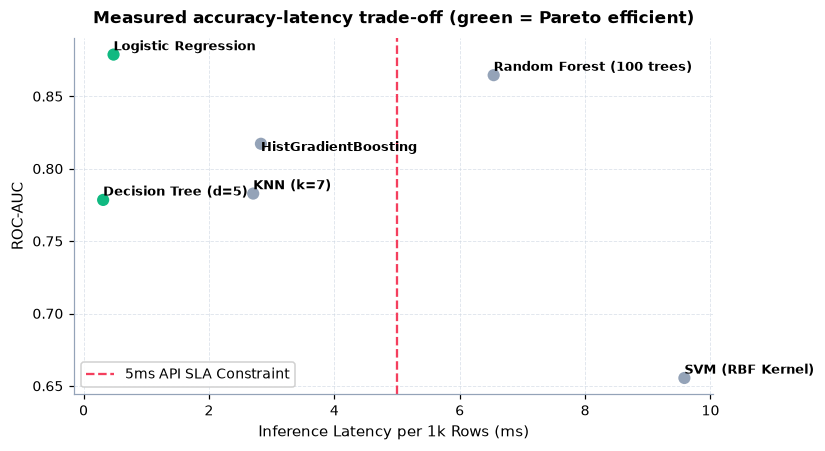

                    Model   AUC  Latency_ms  Size_KB  Pareto
      Decision Tree (d=5) 0.778       0.312      4.4    True
      Logistic Regression 0.879       0.478      1.3    True
                KNN (k=7) 0.783       2.706     89.7   False
     HistGradientBoosting 0.817       2.829    215.0   False
Random Forest (100 trees) 0.865       6.542    737.3   False
         SVM (RBF Kernel) 0.655       9.584     12.8   False

Within this machine's 5ms-per-1,000-row budget: Logistic Regression leads at AUC=0.879.
Latency depends on hardware, batch size, warm-up, and concurrency; benchmark the production-shaped path.


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
import pickle, time

bench = make_churn_panel(n_users=3000, snapshots_per_user=1, seed=SEED)
X_bench = bench[["tenure_days", "monthly_spend", "logins_30d"]]
y_bench = bench["churned"]
X_btr, X_bte, y_btr, y_bte = X_bench.iloc[:2000], X_bench.iloc[2000:], y_bench.iloc[:2000], y_bench.iloc[2000:]
models = {
    "Logistic Regression": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "Decision Tree (d=5)": DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "Random Forest (100 trees)": RandomForestClassifier(n_estimators=100, max_depth=7, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=60, random_state=SEED),
    "SVM (RBF Kernel)": Pipeline([("scale", StandardScaler()), ("model", SVC())]),
    "KNN (k=7)": Pipeline([("scale", StandardScaler()), ("model", KNeighborsClassifier(7))]),
}

rows = []
for name, model in models.items():
    model.fit(X_btr, y_btr)
    scores = model.predict_proba(X_bte)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_bte)
    _ = model.predict(X_bte)  # warm-up
    t0 = time.perf_counter()
    for _ in range(20):
        _ = model.predict(X_bte)
    latency_ms = (time.perf_counter() - t0) * 1000 / 20
    rows.append((name, roc_auc_score(y_bte, scores), latency_ms, len(pickle.dumps(model)) / 1024))

models_data = pd.DataFrame(rows, columns=["Model", "AUC", "Latency_ms", "Size_KB"])
models_data["Pareto"] = [
    not ((models_data["Latency_ms"] <= row.Latency_ms) & (models_data["AUC"] >= row.AUC)
         & ((models_data["Latency_ms"] < row.Latency_ms) | (models_data["AUC"] > row.AUC))).any()
    for row in models_data.itertuples()
]

plt.figure(figsize=(7.5, 4.2))
colors = np.where(models_data["Pareto"], COLOR_TRAIN, COLOR_NEUTRAL)
plt.scatter(models_data["Latency_ms"], models_data["AUC"], color=colors, s=90, edgecolors="white", lw=1.5)

for _, r in models_data.iterrows():
    offset_y = 0.003 if r["Model"] != "HistGradientBoosting" else -0.005
    plt.annotate(r["Model"], (r["Latency_ms"], r["AUC"] + offset_y), fontsize=8.5, fontweight="bold")

plt.axvline(5.0, color=COLOR_VAL, linestyle="--", label="5ms API SLA Constraint")
plt.title("Measured accuracy-latency trade-off (green = Pareto efficient)")
plt.xlabel("Inference Latency per 1k Rows (ms)")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

print(models_data.sort_values("Latency_ms").round({"AUC": 3, "Latency_ms": 3, "Size_KB": 1}).to_string(index=False))
eligible = models_data[models_data["Latency_ms"] <= 5.0].sort_values("AUC", ascending=False)
if len(eligible):
    winner = eligible.iloc[0]
    print(f"\nWithin this machine's 5ms-per-1,000-row budget: {winner['Model']} leads at AUC={winner['AUC']:.3f}.")
else:
    print("\nNo candidate met the illustrative 5ms budget on this machine.")
print("Latency depends on hardware, batch size, warm-up, and concurrency; benchmark the production-shaped path.")


> 🎤 **In an interview:** "Model selection is constrained optimization: I maximize target metric subject to latency SLA, memory footprint, and interpretability constraints. Within a 5ms SLA, gradient boosting dominates deep forests and kernel SVMs." 

---
## 4.2 Ensemble Methods: Bagging vs Boosting Variance Reduction 🔴 (10 min)
> 📖 **Website:** [Ensemble Methods](http://localhost:5173/#ensembles)

**The question:** How much does bagging reduce prediction variance, and how does boosting reduce systematic error as stages are added?

**What you'll see:** We refit trees across bootstrap datasets to estimate model variance, then average staged boosting predictions across repeated noisy samples to track squared bias.

Single Unpruned Tree Average Variance : 0.0353
Bagged Ensemble Average Variance       : 0.0062

Empirical Variance Reduction Ratio    : 82.5% variance reduction achieved through aggregation!


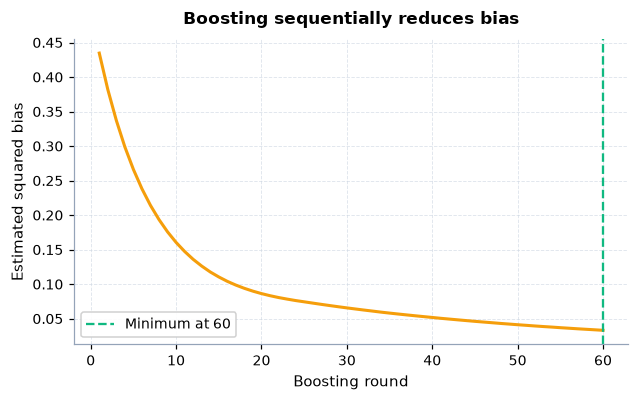

Boosting squared bias: round 1=0.4347, minimum=0.0332 at round 60.


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

df_ens = make_churn_panel(n_users=2500, snapshots_per_user=1, seed=SEED)
X_ens = df_ens[["tenure_days", "monthly_spend", "logins_30d"]].values
y_ens = df_ens["churned"].values

X_tr_e, X_te_e = X_ens[:1800], X_ens[1800:]
y_tr_e, y_te_e = y_ens[:1800], y_ens[1800:]

# Train 80 bootstrap single trees vs 80-tree Bagging
N_BOOT = 60
single_tree_preds = np.zeros((N_BOOT, len(X_te_e)))
bag_preds = np.zeros((N_BOOT, len(X_te_e)))

rng = np.random.RandomState(SEED)
for b in range(N_BOOT):
    idx = rng.choice(len(X_tr_e), len(X_tr_e), replace=True)
    tree = DecisionTreeClassifier(max_depth=None, random_state=b).fit(X_tr_e[idx], y_tr_e[idx])
    single_tree_preds[b, :] = tree.predict_proba(X_te_e)[:, 1]
    
    bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=25, random_state=b).fit(X_tr_e[idx], y_tr_e[idx])
    bag_preds[b, :] = bag.predict_proba(X_te_e)[:, 1]

var_single = np.mean(np.var(single_tree_preds, axis=0))
var_bag = np.mean(np.var(bag_preds, axis=0))
var_reduction = 1.0 - (var_bag / var_single)

print(f"Single Unpruned Tree Average Variance : {var_single:.4f}")
print(f"Bagged Ensemble Average Variance       : {var_bag:.4f}")
print(f"\nEmpirical Variance Reduction Ratio    : {var_reduction:.1%} variance reduction achieved through aggregation!")

# Boosting: estimate squared bias at each stage across repeated noisy training sets
from sklearn.ensemble import GradientBoostingRegressor
grid = np.linspace(0, 1, 150).reshape(-1, 1)
truth = np.sin(2 * np.pi * grid.ravel())
n_rounds, n_repeats = 60, 25
mean_stage_predictions = np.zeros((n_rounds, len(grid)))
for repeat in range(n_repeats):
    rng_b = np.random.RandomState(SEED + repeat)
    X_b = rng_b.uniform(0, 1, size=(120, 1))
    y_b = np.sin(2 * np.pi * X_b.ravel()) + rng_b.normal(0, 0.25, len(X_b))
    boost = GradientBoostingRegressor(n_estimators=n_rounds, max_depth=1, learning_rate=0.08, random_state=repeat).fit(X_b, y_b)
    for stage, pred in enumerate(boost.staged_predict(grid)):
        mean_stage_predictions[stage] += pred / n_repeats

bias_sq_by_round = np.mean((mean_stage_predictions - truth) ** 2, axis=1)
best_round = int(np.argmin(bias_sq_by_round) + 1)
plt.figure(figsize=(6.5, 3.6))
plt.plot(np.arange(1, n_rounds + 1), bias_sq_by_round, color=COLOR_BIAS, lw=2)
plt.axvline(best_round, color=COLOR_TRAIN, linestyle="--", label=f"Minimum at {best_round}")
plt.xlabel("Boosting round"); plt.ylabel("Estimated squared bias"); plt.title("Boosting sequentially reduces bias")
plt.legend(); plt.show()
print(f"Boosting squared bias: round 1={bias_sq_by_round[0]:.4f}, minimum={bias_sq_by_round[best_round-1]:.4f} at round {best_round}.")


### 📝 Exercise 4.2: Bagging Variance Reduction
Verify the variance reduction calculation.

In [4]:
# ── Exercise 4.2 ────────────────────────────────────────────────
def calc_variance_ratio(var_single: float, var_ensemble: float) -> float:
    return var_ensemble / var_single

check_4_2(calc_variance_ratio)


✅ Correct! Variance reduction ratio is 0.125 (87.5% variance reduction).


> 🎤 **In an interview:** "Bagging trains high-capacity, low-bias models in parallel on bootstrap samples, driving variance down by $\frac{1}{B}$ if uncorrelated. Boosting trains shallow, high-bias models sequentially, fitting pseudo-residuals to systematically drive bias down." 

---
## 4.3 PCA: Explained Variance & The Standardization Trap 🟠 (8 min)
> 📖 **Website:** [Dimensionality Reduction](http://localhost:5173/#dimensionality-reduction)

**The question:** What happens to PCA loadings if you forget to standardize features with mismatched units?

**What you'll see:** We reproduce the website's **PCA Lab**, select a 95%-variance dimension programmatically, and construct a failure case where the low-variance direction is the predictive one.

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate correlated Age vs Income matching PCA Lab
rng = np.random.RandomState(90210)
z1 = rng.normal(0, 1, 150)
z2 = rng.normal(0, 1, 150)
age = 45 + 9 * z1
income = 90 + 28 * (0.72 * z1 + np.sqrt(1 - 0.72**2) * z2)

X_pca_raw = np.c_[age, income]
X_pca_std = StandardScaler().fit_transform(X_pca_raw)

pca_raw = PCA(n_components=2).fit(X_pca_raw)
pca_std = PCA(n_components=2).fit(X_pca_std)

print("PCA Loadings on RAW Units (Age in Years vs Income in Thousands):")
print(f"PC1 Vector: Age loading = {pca_raw.components_[0, 0]:.3f}, Income loading = {pca_raw.components_[0, 1]:.3f}")
print(f"Explained Variance: PC1 = {pca_raw.explained_variance_ratio_[0]:.1%}, PC2 = {pca_raw.explained_variance_ratio_[1]:.1%}")

print("\nPCA Loadings on STANDARDIZED Units:")
print(f"PC1 Vector: Age loading = {pca_std.components_[0, 0]:.3f}, Income loading = {pca_std.components_[0, 1]:.3f}")
print(f"Explained Variance: PC1 = {pca_std.explained_variance_ratio_[0]:.1%}, PC2 = {pca_std.explained_variance_ratio_[1]:.1%}")
print(f"\nConclusion: Without standardization, PC1 is hijacked by income's measurement scale.")

# Cumulative variance: choose dimensionality rather than eyeballing it
from sklearn.datasets import load_wine
wine_X, _ = load_wine(return_X_y=True)
wine_scaled = StandardScaler().fit_transform(wine_X)
wine_pca = PCA().fit(wine_scaled)
n_95 = int(np.searchsorted(np.cumsum(wine_pca.explained_variance_ratio_), 0.95) + 1)
print(f"Wine dataset: {n_95} of {wine_X.shape[1]} standardized components reach at least 95% explained variance.")

# PCA is unsupervised: low variance can still carry nearly all target signal
from sklearn.metrics import accuracy_score
rng_fail = np.random.RandomState(SEED)
y_fail = rng_fail.randint(0, 2, 1200)
high_variance_noise = rng_fail.normal(0, [12, 8, 5, 3], size=(1200, 4))
low_variance_signal = (0.08 * (2 * y_fail - 1) + rng_fail.normal(0, 0.01, 1200)).reshape(-1, 1)
X_fail = np.c_[high_variance_noise, low_variance_signal]
Xf_tr, Xf_te, yf_tr, yf_te = X_fail[:800], X_fail[800:], y_fail[:800], y_fail[800:]
pca_two = PCA(n_components=2).fit(Xf_tr)
lr_pca = LogisticRegression().fit(pca_two.transform(Xf_tr), yf_tr)
lr_all = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression())]).fit(Xf_tr, yf_tr)
print(f"Predictive low-variance direction: PCA(2) accuracy={accuracy_score(yf_te, lr_pca.predict(pca_two.transform(Xf_te))):.3f}; all scaled features={accuracy_score(yf_te, lr_all.predict(Xf_te)):.3f}.")


PCA Loadings on RAW Units (Age in Years vs Income in Thousands):
PC1 Vector: Age loading = 0.252, Income loading = 0.968
Explained Variance: PC1 = 94.1%, PC2 = 5.9%

PCA Loadings on STANDARDIZED Units:
PC1 Vector: Age loading = 0.707, Income loading = 0.707
Explained Variance: PC1 = 83.7%, PC2 = 16.3%

Conclusion: Without standardization, PC1 is hijacked by income's measurement scale.
Wine dataset: 10 of 13 standardized components reach at least 95% explained variance.
Predictive low-variance direction: PCA(2) accuracy=0.482; all scaled features=1.000.


> 🎤 **In an interview:** "PCA preserves variance, not predictive signal. I standardize when units are arbitrary, retain raw scale when variance itself is meaningful, choose components inside cross-validation, and verify that discarded low-variance directions are not target-informative." 

---
## 4.4 Clustering: K-Means From Scratch & DBSCAN Comparison 🟢 (8 min)
> 📖 **Website:** [Clustering Fundamentals](http://localhost:5173/#clustering)

**The question:** How does K-Means optimize within-cluster sum of squares (inertia), and where does its spherical assumption fail?

**What you'll see:** 
1. K-Means implemented from scratch (<25 lines) matching scikit-learn inertia.
2. The Failure Gallery: K-Means failing on non-spherical concentric rings while DBSCAN succeeds.

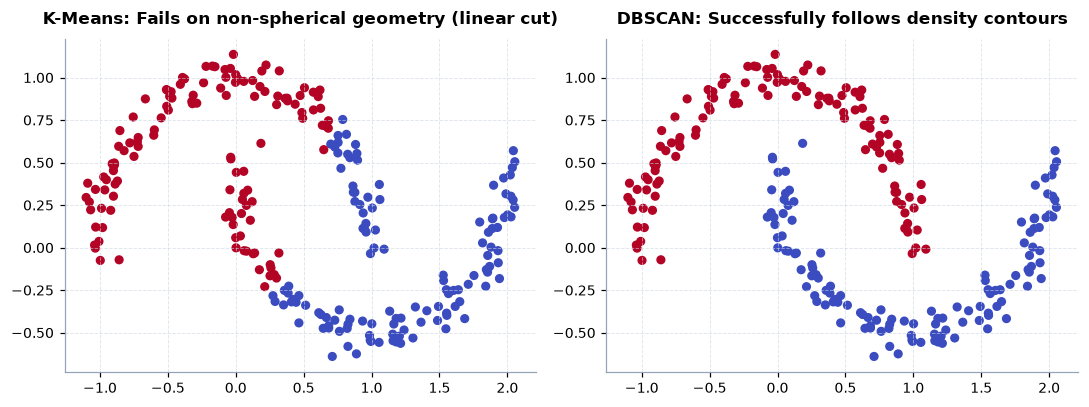

 k   Inertia  Silhouette
 2 14950.701       0.598
 3  4052.432       0.779
 4   664.639       0.840
 5   590.900       0.717
 6   528.683       0.592
Silhouette selects k=4; best-achievable inertia is non-increasing and has no useful literal minimum before k=n.
n_init=1 sensitivity across 10 seeds: inertia range 1182.9–9983.2.


In [6]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons

# 1. K-Means from Scratch in NumPy
def kmeans_scratch(X, k=3, max_iter=40, seed=42):
    rng = np.random.RandomState(seed)
    centroids = X[rng.choice(len(X), k, replace=False)]
    for _ in range(max_iter):
        # Assign
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        # Recompute
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else centroids[j] for j in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    inertia = np.sum((X - centroids[labels])**2)
    return centroids, labels, inertia

# 2. Failure Gallery: Two Moons (Non-convex manifolds)
X_moons, _ = make_moons(n_samples=250, noise=0.07, random_state=SEED)

km_moons = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(X_moons)
db_moons = DBSCAN(eps=0.22, min_samples=5).fit(X_moons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap="coolwarm", s=25)
ax1.set_title("K-Means: Fails on non-spherical geometry (linear cut)")

ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=db_moons.labels_, cmap="coolwarm", s=25)
ax2.set_title("DBSCAN: Successfully follows density contours")

plt.tight_layout()
plt.show()

# Elbow, silhouette, and initialization sensitivity on compact blobs
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
X_blobs, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.85, random_state=SEED)
cluster_rows = []
for k in range(2, 7):
    fitted = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_blobs)
    cluster_rows.append((k, fitted.inertia_, silhouette_score(X_blobs, fitted.labels_)))
cluster_df = pd.DataFrame(cluster_rows, columns=["k", "Inertia", "Silhouette"])
print(cluster_df.round(3).to_string(index=False))
print(f"Silhouette selects k={cluster_df.loc[cluster_df['Silhouette'].idxmax(), 'k']:.0f}; best-achievable inertia is non-increasing and has no useful literal minimum before k=n.")

X_init, _ = make_blobs(n_samples=500, centers=5, cluster_std=[0.3, 2.0, 0.5, 1.5, 0.8], random_state=SEED)
single_start_inertias = [KMeans(n_clusters=5, n_init=1, init="random", random_state=s).fit(X_init).inertia_ for s in range(10)]
print(f"n_init=1 sensitivity across 10 seeds: inertia range {min(single_start_inertias):.1f}–{max(single_start_inertias):.1f}.")


### 📝 Exercise 4.4: K-Means Verification
Check the custom K-Means function with `check_4_4`.

In [7]:
# ── Exercise 4.4 ────────────────────────────────────────────────
check_4_4(kmeans_scratch)


✅ Correct! K-Means converged with final inertia = 157.52.


> 🎤 **In an interview:** "K-Means minimizes squared Euclidean distance, favoring compact convex clusters and remaining sensitive to scale and initialization. I compare multiple restarts and silhouette stability; for non-convex shapes I may try DBSCAN, while checking its density assumptions and noise labels." 

---
## 4.5 Capstone: End-to-End Production Pipeline 🔴 (15 min)
> 📖 **Website:** [ML Pipeline](http://localhost:5173/#pipeline)

**The question:** How do you construct a leakage-free, production-grade ML pipeline from raw multi-type data to serialization and test-set verification?

**What you'll see:** The complete 11-step production pipeline:
1. Define the target, prediction timestamp, ranking metric, and error costs.
2. Audit feature availability and remove post-outcome columns.
3. Create user-disjoint January/February/March train/validation/test partitions.
4. Put all preprocessing inside a `ColumnTransformer`.
5. Measure a no-skill baseline.
6. Compare two candidates on identical folds.
7. Tune only on training folds.
8. Freeze a cost-sensitive threshold on validation data.
9. Open test once and report bootstrap uncertainty.
10. Persist and reload the entire pipeline.
11. Emit a model card and demonstrate train/serve skew.

**Problem framing:** At each monthly snapshot, predict churn in the next 30 days using only fields available at scoring time. Primary ranking metric: PR-AUC; guardrail: ROC-AUC. False positive cost: $8; false negative cost: $400.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from mlprep.preprocessing import make_target_encoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.base import clone
import joblib

# 1–3. Load, audit, and create three sealed boundaries (both time- and user-disjoint)
df_full = make_churn_panel(n_users=4000, snapshots_per_user=3, seed=SEED)
users = np.array(sorted(df_full["user_id"].unique()))
rng_split = np.random.RandomState(SEED); rng_split.shuffle(users)
train_users, val_users, test_users = set(users[:2800]), set(users[2800:3400]), set(users[3400:])
train_raw = df_full[df_full["user_id"].isin(train_users) & (df_full["snapshot_date"] == "2025-01-01")].copy()
val_raw = df_full[df_full["user_id"].isin(val_users) & (df_full["snapshot_date"] == "2025-02-01")].copy()
test_raw = df_full[df_full["user_id"].isin(test_users) & (df_full["snapshot_date"] == "2025-03-01")].copy()
assert train_users.isdisjoint(val_users | test_users) and val_users.isdisjoint(test_users)
assert train_raw["snapshot_date"].max() < val_raw["snapshot_date"].min() < test_raw["snapshot_date"].min()

num_features = ["tenure_days", "monthly_spend", "logins_30d", "income"]
cat_low_card, cat_high_card = ["device"], ["plan_region"]
features = num_features + cat_low_card + cat_high_card
known_leaks = {"cancellation_reason_code", "support_tickets_30d"}
assert known_leaks.isdisjoint(features)
X_train, y_train = train_raw[features], train_raw["churned"]
X_val, y_val = val_raw[features], val_raw["churned"]
X_test, y_test = test_raw[features], test_raw["churned"]
print(f"Sealed rows: train={len(X_train)}, validation={len(X_val)}, test={len(X_test)}; user overlap=0; dates strictly increase.")

# 4. All learned transformations live inside the pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)), ("scale", StandardScaler())]), num_features),
    ("one_hot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_low_card),
    ("target_encode", make_target_encoder(SEED), cat_high_card),
])
logistic = Pipeline([("prep", clone(preprocessor)), ("clf", LogisticRegression(max_iter=1500))])
boosting = Pipeline([("prep", clone(preprocessor)), ("clf", HistGradientBoostingClassifier(random_state=SEED))])

# 5–7. Baseline, identical candidate folds, and modest training-only search
dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)
dummy_val_ap = average_precision_score(y_val, dummy.predict_proba(X_val)[:, 1])
cv_splits = list(StratifiedKFold(3, shuffle=True, random_state=SEED).split(X_train, y_train))
lr_cv = cross_val_score(logistic, X_train, y_train, cv=cv_splits, scoring="average_precision")
hgb_cv = cross_val_score(boosting, X_train, y_train, cv=cv_splits, scoring="average_precision")
if lr_cv.mean() >= hgb_cv.mean():
    selected_family = "logistic regression"
    search_estimator = logistic
    search_space = {"clf__C": np.logspace(-2, 2, 20), "clf__class_weight": [None, "balanced"]}
else:
    selected_family = "histogram gradient boosting"
    search_estimator = boosting
    search_space = {"clf__learning_rate": [0.03, 0.06, 0.1], "clf__max_leaf_nodes": [7, 15, 31], "clf__min_samples_leaf": [15, 30, 50]}
search = RandomizedSearchCV(
    search_estimator, search_space,
    n_iter=6, scoring="average_precision", cv=cv_splits, random_state=SEED, refit=True,
).fit(X_train, y_train)
best_pipeline = search.best_estimator_
print(f"Validation no-skill PR-AUC={dummy_val_ap:.3f}; CV logistic={lr_cv.mean():.3f}±{lr_cv.std():.3f}; CV boosting={hgb_cv.mean():.3f}±{hgb_cv.std():.3f}.")
print(f"Selected family={selected_family}; tuned training-CV PR-AUC={search.best_score_:.3f}; params={search.best_params_}")

# 8. Freeze the operating threshold on validation data only
COST_FP, COST_FN = 8.0, 400.0
val_probs = best_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.unique(np.r_[0.0, val_probs, 1.0])
val_costs = []
for threshold in thresholds:
    tn, fp, fn, tp = confusion_matrix(y_val, val_probs >= threshold).ravel()
    val_costs.append(fp * COST_FP + fn * COST_FN)
operating_threshold = float(thresholds[np.argmin(val_costs)])

# 9. Open the test set once; quantify sampling uncertainty
test_probs = best_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
test_prauc = average_precision_score(y_test, test_probs)
tn, fp, fn, tp = confusion_matrix(y_test, test_probs >= operating_threshold).ravel()
test_cost = fp * COST_FP + fn * COST_FN
rng_boot = np.random.RandomState(SEED)
auc_boot, ap_boot = [], []
for _ in range(300):
    idx = rng_boot.choice(len(y_test), len(y_test), replace=True)
    if y_test.iloc[idx].nunique() == 2:
        auc_boot.append(roc_auc_score(y_test.iloc[idx], test_probs[idx]))
        ap_boot.append(average_precision_score(y_test.iloc[idx], test_probs[idx]))
auc_ci, ap_ci = np.percentile(auc_boot, [2.5, 97.5]), np.percentile(ap_boot, [2.5, 97.5])
print(f"Frozen threshold={operating_threshold:.3f} | Test cost=${test_cost:,.0f} | TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Test ROC-AUC={test_auc:.3f} (95% bootstrap CI {auc_ci[0]:.3f}–{auc_ci[1]:.3f})")
print(f"Test PR-AUC ={test_prauc:.3f} (95% bootstrap CI {ap_ci[0]:.3f}–{ap_ci[1]:.3f})")

# 10. Ship the entire fitted transformation + model graph
os.makedirs("artifacts", exist_ok=True)
pipeline_path = "artifacts/churn_production_pipeline.joblib"
joblib.dump(best_pipeline, pipeline_path)
reloaded_pipeline = joblib.load(pipeline_path)
reloaded_probs = reloaded_pipeline.predict_proba(X_test)[:, 1]
assert np.array_equal(test_probs, reloaded_probs)
print(f"Reload check: bit-for-bit identical ✅ | {pipeline_path} ({os.path.getsize(pipeline_path)/1024:.1f} KB)")

# 11. Model card + one-row train/serve-skew demonstration
model_card = pd.Series({
    "Target / horizon": "churn in next 30 days at monthly snapshot",
    "Training window": "2025-01-01 synthetic cohort",
    "Features": ", ".join(features),
    "Primary metric": f"test PR-AUC {test_prauc:.3f}",
    "Operating threshold": f"{operating_threshold:.3f}",
    "Known limitations": "synthetic data; unseen drift, fairness, and delayed-label behavior not established",
    "Retraining trigger": "material feature/prevalence drift or sustained metric/cost degradation",
}, name="Model card")
display(model_card.to_frame())

incoming = X_test.iloc[[0]]
good_prob = reloaded_pipeline.predict_proba(incoming)[0, 1]
manual_features = reloaded_pipeline.named_steps["prep"].transform(incoming).copy()
manual_features[0, [0, 1]] = manual_features[0, [1, 0]]  # subtle schema-order bug
bad_prob = reloaded_pipeline.named_steps["clf"].predict_proba(manual_features)[0, 1]
print(f"One-row score through saved pipeline={good_prob:.5f}; corrupted manual feature order={bad_prob:.5f}; delta={bad_prob-good_prob:+.5f}.")


Sealed rows: train=2800, validation=600, test=600; user overlap=0; dates strictly increase.


Validation no-skill PR-AUC=0.062; CV logistic=0.410±0.025; CV boosting=0.281±0.033.
Selected family=logistic regression; tuned training-CV PR-AUC=0.411; params={'clf__class_weight': None, 'clf__C': np.float64(0.7847599703514611)}


Frozen threshold=0.012 | Test cost=$2,752 | TP=42, FP=244, FN=2, TN=312
Test ROC-AUC=0.902 (95% bootstrap CI 0.855–0.943)
Test PR-AUC =0.534 (95% bootstrap CI 0.398–0.705)
Reload check: bit-for-bit identical ✅ | artifacts/churn_production_pipeline.joblib (9.0 KB)


,Model card
Target / horizon,churn in next 30 days at monthly snapshot
Training window,2025-01-01 synthetic cohort
Features,"tenure_days, monthly_spend, logins_30d, income..."
Primary metric,test PR-AUC 0.534
Operating threshold,0.012
Known limitations,"synthetic data; unseen drift, fairness, and de..."
Retraining trigger,material feature/prevalence drift or sustained...


One-row score through saved pipeline=0.00396; corrupted manual feature order=0.01638; delta=+0.01242.


> 🎤 **In an interview:** "I encapsulate all imputers, scalers, and out-of-fold encoders inside a single scikit-learn `Pipeline` or `ColumnTransformer`. I serialize the entire pipeline object—not bare model weights—eliminating training-serving skew by guaranteeing identical feature transformations at runtime." 

---
## 4.6 Post-Fit Error Analysis & Monitoring 🟠 (7 min)
> 📖 **Website:** [ML Pipeline](http://localhost:5173/#pipeline)

**The question:** A global test score is acceptable—what do you inspect before deployment, and what do you monitor afterward?

**What you'll see:** Validation-only permutation importance, test performance slices with sample sizes, and a population-stability index (PSI) example. These are diagnostic signals, not automatic causal explanations or universal alert thresholds.

In [9]:
from sklearn.inspection import permutation_importance

# Importance on validation data avoids adapting the final test result
perm = permutation_importance(best_pipeline, X_val, y_val, scoring="average_precision", n_repeats=5, random_state=SEED)
importance = pd.DataFrame({"Feature": features, "Mean PR-AUC decrease": perm.importances_mean, "Std": perm.importances_std})
print("Validation permutation importance (correlated features can share/dilute importance):")
print(importance.sort_values("Mean PR-AUC decrease", ascending=False).round(3).to_string(index=False))

# Post-test slice audit: show uncertainty context through n and positive count
slice_rows = []
for device, idx in test_raw.groupby("device").groups.items():
    positions = test_raw.index.get_indexer(idx)
    y_slice, p_slice = y_test.loc[idx], test_probs[positions]
    ap = average_precision_score(y_slice, p_slice) if y_slice.nunique() == 2 else np.nan
    slice_rows.append((device, len(idx), int(y_slice.sum()), y_slice.mean(), ap))
print("\nTest slices (hypothesis-generating; small slices need intervals and domain review):")
print(pd.DataFrame(slice_rows, columns=["Device", "n", "Positives", "Prevalence", "PR-AUC"]).round(3).to_string(index=False))

# Simple feature-drift example: PSI using bins fixed from training
edges = np.unique(np.quantile(train_raw["tenure_days"], np.linspace(0, 1, 11)))
edges[[0, -1]] = [-np.inf, np.inf]
train_prop = pd.cut(train_raw["tenure_days"], edges).value_counts(normalize=True, sort=False).to_numpy()
test_prop = pd.cut(test_raw["tenure_days"], edges).value_counts(normalize=True, sort=False).to_numpy()
eps = 1e-6
psi = np.sum((test_prop - train_prop) * np.log((test_prop + eps) / (train_prop + eps)))
print(f"\nTenure PSI from train to test={psi:.3f}. Alert thresholds must be calibrated to seasonality and business impact.")


Validation permutation importance (correlated features can share/dilute importance):
      Feature  Mean PR-AUC decrease   Std
   logins_30d                 0.235 0.023
  tenure_days                 0.100 0.025
monthly_spend                 0.026 0.011
       device                 0.012 0.016
       income                 0.007 0.007
  plan_region                 0.006 0.005

Test slices (hypothesis-generating; small slices need intervals and domain review):
 Device   n  Positives  Prevalence  PR-AUC
Android 186          9       0.048   0.360
Desktop  62          4       0.065   0.650
    Web  96          8       0.083   0.657
    iOS 256         23       0.090   0.608

Tenure PSI from train to test=0.169. Alert thresholds must be calibrated to seasonality and business impact.


> 🎤 **In an interview:** "After the global metric, I inspect errors and calibrated performance by meaningful slices with uncertainty. In production I monitor schema, feature and prevalence drift, calibration, decision cost, latency, and delayed-label performance—then tie alerts to an explicit response." 

---
## 4.7 Debugging Drills 🔴 (10 min)
> 📖 **Website:** [Common Interview Questions](http://localhost:5173/#interview-questions)

Eight realistic code snippets with one primary defect each. Spot the flaw, then review its operational impact:

### Drill 1: Preprocessing Split Order
```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Flaw!
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** `fit_transform` on the entire dataset leaks the global mean and standard deviation of the test set into the training representations.
* **The Fix:** Fit the scaler strictly on `X_train`, and call `transform` on `X_test`.
* **Impact:** Distorts out-of-sample error estimates, especially under distribution shift or outliers.
</details>

---

### Drill 2: Temporal Cross-Validation
```python
# Monthly financial panel data
cv = KFold(n_splits=5, shuffle=True) # Flaw!
scores = cross_val_score(model, X_time_series, y_time_series, cv=cv)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Shuffled K-Fold on time-series data uses future observations to predict past events, causing lookahead temporal leakage.
* **The Fix:** Use `TimeSeriesSplit(n_splits=5)` or expanding-window chronological splits.
* **Impact:** The direction and size depend on drift; the estimate is invalid because future observations influenced earlier folds.
</details>

---

### Drill 3: Resampling Test Data
```python
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y) # Flaw!
X_tr, X_te, y_tr, y_te = train_test_split(X_res, y_res, test_size=0.2)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Applying SMOTE before splitting synthesizes points that blend train and test distributions, evaluating on artificial test data.
* **The Fix:** Place `SMOTE` inside an `imblearn.pipeline.Pipeline` applied only to training folds.
* **Impact:** Synthetic neighbors derived from would-be test observations can appear in training, making the estimate confidently optimistic.
</details>

---

### Drill 4: Validation Set Transformation
```python
imputer = SimpleImputer(strategy="mean")
X_tr_imp = imputer.fit_transform(X_tr)
X_val_imp = imputer.fit_transform(X_val) # Flaw!
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Calling `fit_transform` on validation/test recalculates imputation statistics from the evaluation split rather than using the learned training pipeline parameters.
* **The Fix:** Call `imputer.transform(X_val)`.
</details>


---

### Drill 5: Comparing Models on Different Splits
```python
score_a = cross_val_score(model_a, X, y, cv=KFold(5, shuffle=True, random_state=1)).mean()
score_b = cross_val_score(model_b, X, y, cv=KFold(5, shuffle=True, random_state=9)).mean()  # Flaw!
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Model and split variability are confounded, so the score difference is not a paired comparison.
* **The Fix:** Materialize one set of fold indices and pass the identical folds to both models; report fold-wise differences and uncertainty.
* **Impact:** On small data, split-to-split variance can be larger than the apparent model improvement.
</details>

---

### Drill 6: Accuracy on a 1% Positive Problem
```python
y_pred = np.zeros_like(y_true)
print(accuracy_score(y_true, y_pred))  # 0.99, therefore "great"? Flaw!
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** A classifier that never detects a positive gets 99% accuracy at 1% prevalence, but recall is 0%.
* **The Fix:** Report the confusion matrix, PR-AUC, recall/precision at the operating threshold, and precision at capacity; compare with the prevalence baseline.
* **Impact:** The displayed 99% accuracy hides complete failure on the class of interest.
</details>

---

### Drill 7: Full-Data Target Encoding
```python
means = df.groupby("merchant_id")["fraud"].mean()  # Flaw!
df["merchant_risk"] = df["merchant_id"].map(means)
scores = cross_val_score(model, df[["merchant_risk"]], df["fraud"], cv=5)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Each validation label contributes to its own feature value before cross-validation begins.
* **The Fix:** Fit a smoothed target encoder inside the outer training fold; generate training encodings out-of-fold and define an unseen-category prior.
* **Impact:** Rare categories can encode individual labels almost directly, producing severe optimism.
</details>

---

### Drill 8: Tuning on the Test Set
```python
for depth in [2, 4, 8, None]:
    model.set_params(max_depth=depth).fit(X_train, y_train)
    test_scores[depth] = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])  # Flaw!
best_depth = max(test_scores, key=test_scores.get)
```
<details>
<summary>💡 Solution & Flaw Analysis</summary>

* **The Flaw:** Repeatedly selecting against test performance turns the test set into validation data.
* **The Fix:** Tune with training-only cross-validation, freeze the full pipeline and threshold, then open the test set once.
* **Impact:** The winner's test score is optimistically selected; the bias grows with the number of configurations tried.
</details>

---
## 4.8 Interview Readiness Self-Assessment 🔴 (5 min)
> 📖 **Website:** [Final Cheat Sheet](http://localhost:5173/#cheat-sheet)

Review these 12 core competencies. Mark an item complete only after explaining it aloud and implementing or debugging a small example without revealing the solution:

In [10]:
CHECKLIST = [
    ("1. Temporal & Group Splits", "I can implement splits that strictly respect entity groupings and time ordering."),
    ("2. Data Leakage Diagnostics", "I can identify target leakage, temporal leakage, and run top-feature ablation tests."),
    ("3. Bias-Variance Decomposition", "I can explain error as bias² + variance + irreducible noise and map remedies to each."),
    ("4. Metric Selection", "I can choose between ROC-AUC, PR-AUC, Brier score, and MAE/RMSE based on business objectives."),
    ("5. Cost-Sensitive Thresholds", "I can optimize a classification threshold from an explicit business cost matrix without retraining."),
    ("6. Feature Scaling", "I can distinguish distance-sensitive models, regularization/conditioning concerns, and rank-based tree splits."),
    ("7. Missingness Mechanisms", "I can distinguish MCAR, MAR, and MNAR and explain when missingness indicators help."),
    ("8. Categorical Encodings", "I can select between One-Hot, Ordinal, and Out-of-Fold Target Encoding based on cardinality."),
    ("9. Gradient Descent Regimes", "I can diagnose learning rate failure modes (under-stepping vs overshooting divergence)."),
    ("10. Loss Function Convexity", "I can explain why logistic log loss is convex and keeps a strong gradient for confidently wrong predictions."),
    ("11. Regularization Geometry", "I can explain why L1 produces exact sparsity while L2 produces proportional shrinkage."),
    ("12. Production Pipelines", "I can construct, validate, and serialize an end-to-end ColumnTransformer pipeline without train/serve skew."),
]

# Edit this set after a closed-book attempt, for example: {1, 2, 5}
COMPLETED = set()

print("=" * 80)
print("             AI / ML ENGINEER INTERVIEW READINESS CHECKLIST")
print("=" * 80)
for number, (title, desc) in enumerate(CHECKLIST, start=1):
    mark = "x" if number in COMPLETED else " "
    print(f"  [{mark}] {title:<32} : {desc}")
print("=" * 80)
print(f"Closed-book readiness: {len(COMPLETED)}/{len(CHECKLIST)}. Edit COMPLETED only after attempting each item.")


             AI / ML ENGINEER INTERVIEW READINESS CHECKLIST
  [ ] 1. Temporal & Group Splits       : I can implement splits that strictly respect entity groupings and time ordering.
  [ ] 2. Data Leakage Diagnostics      : I can identify target leakage, temporal leakage, and run top-feature ablation tests.
  [ ] 3. Bias-Variance Decomposition   : I can explain error as bias² + variance + irreducible noise and map remedies to each.
  [ ] 4. Metric Selection              : I can choose between ROC-AUC, PR-AUC, Brier score, and MAE/RMSE based on business objectives.
  [ ] 5. Cost-Sensitive Thresholds     : I can optimize a classification threshold from an explicit business cost matrix without retraining.
  [ ] 6. Feature Scaling               : I can distinguish distance-sensitive models, regularization/conditioning concerns, and rank-based tree splits.
  [ ] 7. Missingness Mechanisms        : I can distinguish MCAR, MAR, and MNAR and explain when missingness indicators help.
  [ ] 8. Cat